# Make sure to have "Quotes.csv" to run this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def get_bid_ask(file_path):
    quotes = []
    with open(file_path, 'r') as f:
        import csv
        reader = csv.reader(f)
        for row in reader:
            if len(row) >= 3:
                quotes.append([float(row[0]), float(row[2]), float(row[1])])
    return np.array(quotes)

def load_c_values(R1, R2, S0, theta):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    c_v1_unit = []
    dist0 = nus1_full[1] - nus1_full[0]
    c_v1_unit.append((-np.exp(-dist0/sigs1[0]), np.exp(dist0/sigs1[0])))
    for j in range(R1 - 1):
        P = c_v1_unit[j][0] + c_v1_unit[j][1]
        S = (1/sigs1[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1_full[j+2] - nus1_full[j+1]
        c_v1_unit.append((0.5 * (P - sigs1[j+1]*S) * np.exp(-dist/sigs1[j+1]), 0.5 * (P + sigs1[j+1]*S) * np.exp(dist/sigs1[j+1])))
    c_v2_unit = [None] * R2
    dist_u = nus2_full[-1] - nus2_full[-2]
    c_v2_unit[-1] = (np.exp(dist_u/sigs2[-1]), -np.exp(-dist_u/sigs2[-1]))
    for j in range(R2 - 1, 0, -1):
        P = c_v2_unit[j][0] + c_v2_unit[j][1]
        S = (1/sigs2[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2_full[j] - nus2_full[j-1]
        c_v2_unit[j-1] = (0.5 * (P - sigs2[j-1]*S) * np.exp(dist/sigs2[j-1]), 0.5 * (P + sigs2[j-1]*S) * np.exp(-dist/sigs2[j-1]))
    v1, Dk_v1 = c_v1_unit[-1][0] + c_v1_unit[-1][1], (1/sigs1[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])
    v2, Dk_v2 = c_v2_unit[0][0] + c_v2_unit[0][1], (1/sigs2[0]) * (-c_v2_unit[0][0] + c_v2_unit[0][1])
    denom = (Dk_v1 * v2 - v1 * Dk_v2)
    lam1, lam2 = v2 / denom, v1 / denom
    c_v1 = np.array(c_v1_unit) * lam1
    c_v2 = np.array(c_v2_unit) * lam2
    return c_v1, c_v2

def validate_and_check_market(R1, R2, S0, theta, bid_ask_arr):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    try:
        c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    except:
        return False

    K_vec = bid_ask_arr[:, 0]
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    mask_left = K_vec <= S0
    mask_right = ~mask_left
    results = np.zeros_like(K_vec)

    if np.any(mask_left):
        K_left = K_vec[mask_left]
        indices = np.searchsorted(nus1_full, K_left, side='left') - 1
        indices = np.clip(indices, 0, R1 - 1)
        dist = nus1_full[indices + 1] - K_left
        results[mask_left] = (c_v1[indices, 0] * np.exp(dist/sigs1[indices]) + c_v1[indices, 1] * np.exp(-dist/sigs1[indices])) + S0 - K_left

    if np.any(mask_right):
        K_right = K_vec[mask_right]
        indices = np.searchsorted(nus2_full, K_right, side='left') - 1
        indices = np.clip(indices, 0, R2 - 1)
        dist = K_right - nus2_full[indices]
        results[mask_right] = (c_v2[indices, 0] * np.exp(-dist/sigs2[indices]) + c_v2[indices, 1] * np.exp(dist/sigs2[indices]))

    return np.all((results >= bid_ask_arr[:, 1]) & (results <= bid_ask_arr[:, 2]))

# UPDATE: Objective changed to $$O(θ) = ∑_{i=1}^{R-1} (\frac{1}{σ_i^2} - \frac{1}{σ_{i+1}^2})^2$$

# Also, went back to random coordinate descent since it CCD seemed to get stuck, I have a feeling we were lucky with CCD the first time

In [2]:
def newObjective(sigs):
    return np.log(np.sum(np.diff(1/sigs**2)**2))


def coordinateDescent(R1, R2, S0, init_theta, bid_ask_arr, num_iterations = 2500):
    theta = init_theta.copy()

    for i in range(num_iterations):
        sigs1 = theta[R1 : 2 * R1]
        sigs2 = theta[2 * R1 + R2 :]
        sigs = np.concatenate([sigs1, sigs2])

        if i % 1000 == 0:
            current_loss = newObjective(sigs)
            print(f"Iteration {i}/{num_iterations} | Loss: {current_loss:.6f}")

        grad_sigs = np.zeros_like(sigs)

        # Optimized Vectorized Update Rule:
        # Slice to get neighbors for all internal elements
        s_prev = sigs[:-2]
        s_next = sigs[2:]

        # Perform the calculation for all j from 1 to len(sigs)-2 simultaneously
        target = (np.sqrt(2) * s_prev * s_next) / np.sqrt(s_prev**2 + s_next**2)
        grad_sigs[1:-1] = target - sigs[1:-1]
        grad_sigs[0] = 2*sigs[1] - sigs[2] - sigs[0]
        grad_sigs[-1] = 2*sigs[-2] - sigs[-3] - sigs[-1]

        index = np.random.choice(len(grad_sigs))
        if grad_sigs[index] == 0:
            continue

        update_vector = np.zeros_like(theta)
        if index < R1:
            update_vector[R1 + index] = grad_sigs[index]
        else:
            update_vector[2 * R1 + R2 + (index - R1)] = grad_sigs[index]

        curr_alpha = 1.0
        for b in range(5):
            test_theta = theta + curr_alpha * update_vector
            if validate_and_check_market(R1, R2, S0, test_theta, bid_ask_arr):
                theta = test_theta
                break
            curr_alpha *= 0.5
    return theta

In [3]:
# Diagnostic Functions

def C_K(K, R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    if K <= S0:
        nus1_full = np.concatenate([nus1, [S0]])
        index = np.searchsorted(nus1_full, K, side='left') - 1
        index = np.clip(index, 0, R1 - 1)
        dist = nus1_full[index + 1] - K
        return (c_v1[index, 0] * np.exp(dist/sigs1[index]) + c_v1[index, 1] * np.exp(-dist/sigs1[index])) + S0 - K
    else:
        nus2_full = np.concatenate([[S0], nus2])
        index = np.searchsorted(nus2_full, K, side='left') - 1
        index = np.clip(index, 0, R2 - 1)
        dist = K - nus2_full[index]
        return (c_v2[index, 0] * np.exp(-dist/sigs2[index]) + c_v2[index, 1] * np.exp(dist/sigs2[index]))

def V_K(K, R1, R2, S0, theta, c_v1, c_v2):
    if K >= S0: return C_K(K, R1, R2, S0, theta, c_v1, c_v2)
    else: return  C_K(K, R1, R2, S0, theta, c_v1, c_v2) + K - S0

def C2_over_V(K, R1, R2, S0, theta, c_v1, c_v2):
    return C2_K(K, R1, R2, S0, theta, c_v1, c_v2) / V_K(K, R1, R2, S0, theta, c_v1, c_v2)

def C2_K(K, R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])

    if K <= S0:
        index = np.searchsorted(nus1_full, K, side='left') - 1
        index = np.clip(index, 0, R1 - 1)
        dist = nus1_full[index + 1] - K
        return (1/sigs1[index]**2) * (c_v1[index, 0] * np.exp(dist/sigs1[index]) + c_v1[index, 1] * np.exp(-dist/sigs1[index]))
    else:
        index = np.searchsorted(nus2_full, K, side='left') - 1
        index = np.clip(index, 0, R2 - 1)
        dist = K - nus2_full[index]
        return (1/sigs2[index]**2) * (c_v2[index, 0] * np.exp(-dist/sigs2[index]) + c_v2[index, 1] * np.exp(dist/sigs2[index]))

def calculate_J(R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    jumps = []
    for j in range(R1 - 1):
        v_left = (1/sigs1[j]**2) * (c_v1[j, 0] + c_v1[j, 1])
        dist = nus1_full[j+2] - nus1_full[j+1]
        v_right = (1/sigs1[j+1]**2) * (c_v1[j+1, 0]*np.exp(dist/sigs1[j+1]) + c_v1[j+1, 1]*np.exp(-dist/sigs1[j+1]))
        jumps.append(v_right - v_left)
    v1_S0 = (1/sigs1[-1]**2) * (c_v1[-1, 0] + c_v1[-1, 1])
    v2_S0 = (1/sigs2[0]**2) * (c_v2[0, 0] + c_v2[0, 1])
    jumps.append(v2_S0 - v1_S0)
    for j in range(R2 - 1):
        v_right = (1/sigs2[j+1]**2) * (c_v2[j+1, 0] + c_v2[j+1, 1])
        dist = nus2_full[j+1] - nus2_full[j]
        v_left = (1/sigs2[j]**2) * (c_v2[j, 0]*np.exp(-dist/sigs2[j]) + c_v2[j, 1]*np.exp(dist/sigs2[j]))
        jumps.append(v_right - v_left)
    return np.sum(np.array(jumps) ** 2)

# I reduced the inital number of iterations to 10,000 with RCD since running descent until failure to improve seems to get the optimizer stuck later on.

# Essentially, we are leaving room for further movement in later optimization stages.

Iteration 0/20000 | Loss: -10.612584
Iteration 1000/20000 | Loss: -14.308980
Iteration 2000/20000 | Loss: -14.963042
Iteration 3000/20000 | Loss: -15.413597
Iteration 4000/20000 | Loss: -15.689346
Iteration 5000/20000 | Loss: -15.908322
Iteration 6000/20000 | Loss: -16.066563
Iteration 7000/20000 | Loss: -16.215493
Iteration 8000/20000 | Loss: -16.338631
Iteration 9000/20000 | Loss: -16.447308
Iteration 10000/20000 | Loss: -16.531693
Iteration 11000/20000 | Loss: -16.648320
Iteration 12000/20000 | Loss: -16.727434
Iteration 13000/20000 | Loss: -16.812186
Iteration 14000/20000 | Loss: -16.900311
Iteration 15000/20000 | Loss: -16.984841
Iteration 16000/20000 | Loss: -17.070355
Iteration 17000/20000 | Loss: -17.153427
Iteration 18000/20000 | Loss: -17.218962
Iteration 19000/20000 | Loss: -17.292014


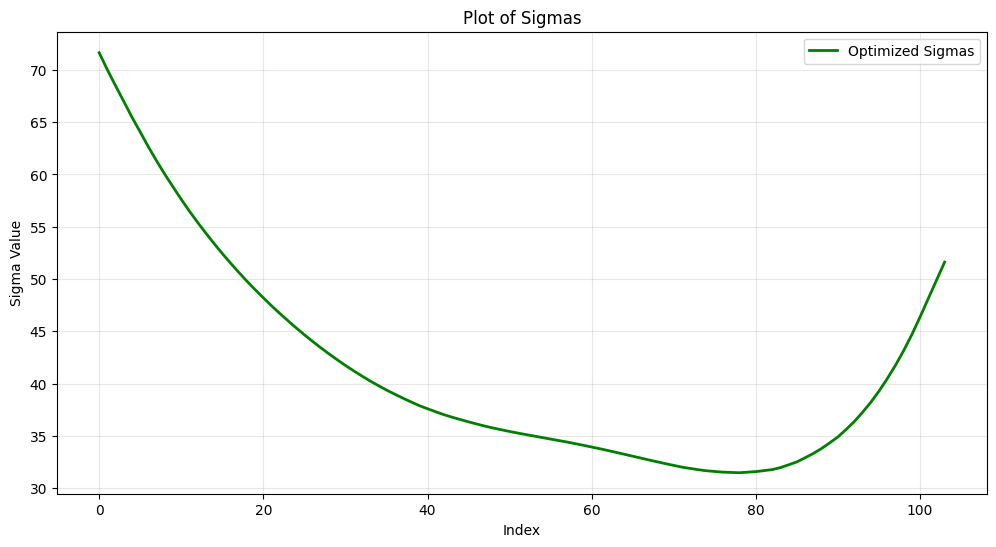

In [4]:
# Model constants
S0 = 1271.87
R1, R2 = 70, 34

# Load market data into NumPy
market_bid_ask = get_bid_ask('Quotes.csv')

# Initial parameters (Converted from your previous lists)
initial_nus1 = np.array([0, 985.8952130330157, 1103.9, 1105.6299717509714, 1108.9, 1110.9261114114317, 1113.9, 1116.0803462760916, 1118.9, 1121.217532062242, 1123.9, 1126.4524566940233, 1128.9, 1131.482542383951, 1133.9, 1136.5181574323626, 1138.9, 1141.5955696582002, 1143.9, 1146.6439410206626, 1148.9, 1151.6955052869373, 1153.9, 1156.7899943184998, 1158.9, 1161.6254606809712, 1163.9, 1166.5610218554195, 1168.9, 1171.459730260086, 1173.9, 1176.4403363141735, 1178.9, 1181.615546573849, 1183.9, 1186.6888172217348, 1188.9, 1191.7378244235415, 1193.9, 1196.5483693501587, 1198.8, 1201.5325443234078, 1203.8, 1206.5944516093734, 1208.8, 1211.4560716332721, 1213.8, 1216.4902257056644, 1218.8, 1221.5020603603978, 1223.8, 1226.3861829743955, 1228.8, 1231.2336479134826, 1233.8, 1236.1780621637572, 1238.8, 1241.7477258299014, 1243.8, 1247.0561689330698, 1248.8, 1251.2009300066638, 1253.8, 1256.2167752285077, 1258.8, 1261.4846983461696, 1263.8, 1265.7099860650808, 1268.8, 1270.5770900753105])
initial_sigs1 = np.array([610.4320996213446, 164.04874695079099, 21.410699478563217, 41.036799095433764, 32.59140099151007, 48.77559067919313, 42.2176372999541, 55.823566769595985, 51.211167181688566, 60.691607330511374, 59.950820637770775, 58.898463641159154, 61.253284806200256, 58.77606559998955, 61.9431978849179, 57.790240203069374, 62.2779153688338, 54.621537161593736, 60.38808834808558, 50.96497274766389, 57.49812984113923, 46.576659253726845, 54.080819207223875, 40.60311710082493, 46.79656147874567, 40.230053767550686, 44.17878499997829, 40.0738197788728, 42.59425882166232, 41.97429249407287, 43.554019179773334, 43.64066412990515, 46.68459597597928, 40.66643248490499, 45.74533322390213, 37.58570160756966, 43.36876861252296, 34.281419881606425, 38.63837902433531, 34.11699307804324, 38.33534468465065, 33.11788846662374, 37.54304297301797, 30.8995436545175, 34.629132576982585, 31.932382438352974, 34.99302768634262, 31.44000481459117, 34.80339761657143, 31.011124152999194, 33.67039062291056, 32.963580616942636, 33.88070107871873, 37.490458108901564, 36.9523875799828, 42.71457754035583, 46.473166992677335, 33.8545330176666, 43.67858033724246, 24.46553767335429, 29.27267842043444, 33.253868886417095, 32.860201483329625, 36.87919843993161, 38.56770262319378, 34.89031672560033, 32.336062185014455, 54.86203086146442, 42.54094598147429, 31.82466458162184])
initial_nus2 = np.array([1272.6042131350682, 1273.8, 1277.3405408056378, 1278.8, 1281.2353139855318, 1283.8, 1286.1696012675789, 1288.8, 1291.2560021979807, 1293.8, 1296.2794535546955, 1298.8, 1301.213819395613, 1303.7, 1306.2617186435, 1308.7, 1311.232700889095, 1313.7, 1316.810048833819, 1323.7, 1327.0068556961314, 1333.7, 1336.0240360741054, 1338.7, 1343.4698860472697, 1353.7, 1356.277830214803, 1358.7, 1361.5021167401464, 1363.7, 1377.3378359299822, 1388.7, 1503.7243622969859, 2000.0])
initial_sigs2 = np.array([24.02631471182734, 38.31350500726014, 64.22160217291687, 24.945880842361603, 31.475272346451945, 31.167940240782592, 29.04149431455202, 30.22926871363152, 28.245473181139502, 27.3473961133823, 26.078699124964757, 24.718907886876814, 23.35903470115683, 22.454368334929534, 22.002320937211316, 19.569326547161026, 19.315256975829875, 17.756271425921597, 19.392408982133873, 39.61543966355491, 26.387286176796366, 49.89596975113815, 28.527769674700764, 31.874820986884167, 41.72362039958813, 83.04797290752168, 40.34143759307382, 37.0089135084597, 39.353339426345215, 30.273572809409785, 73.52830072545393, 57.33057445441953, 169.4372302588361, 313.0441713343745])

init_theta = np.concatenate([initial_nus1, initial_sigs1, initial_nus2, initial_sigs2])

# Run Optimization
opt_theta = coordinateDescent(R1, R2, S0, init_theta, market_bid_ask, num_iterations= 20000)

# Visualize Results
init_sigs = np.concatenate([initial_sigs1, initial_sigs2])
opt_sigs = np.concatenate([opt_theta[R1:2*R1], opt_theta[2*R1+R2:]])

plt.figure(figsize=(12, 6))
# plt.plot(init_sigs, 'r--', alpha=0.6, label='Initial Sigmas')
plt.plot(opt_sigs, 'g-', linewidth=2, label='Optimized Sigmas')
plt.title('Plot of Sigmas')
plt.xlabel('Index')
plt.ylabel('Sigma Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Using the new objective seems to result in a "smoother" graph of sigmas.

# As you can see below, its still really good at reducing J.

In [5]:
# Calculate J for initial parameters
c_v1_init, c_v2_init = load_c_values(R1, R2, S0, init_theta)
j_init = calculate_J(R1, R2, S0, init_theta, c_v1_init, c_v2_init)

# Calculate J for optimized parameters
c_v1_opt, c_v2_opt = load_c_values(R1, R2, S0, opt_theta)
j_opt = calculate_J(R1, R2, S0, opt_theta, c_v1_opt, c_v2_opt)

# Calculate percent reduction
reduction = (j_init - j_opt) / j_init * 100

print(f"Initial J (Jump Metric): {j_init:.8f}")
print(f"Final J (Jump Metric):   {j_opt:.8f}")
print(f"Percent Reduction in J:  {reduction:.2f}%")

Initial J (Jump Metric): 0.00125289
Final J (Jump Metric):   0.00000042
Percent Reduction in J:  99.97%


# A plot of C(K), along with bid-ask ranges.

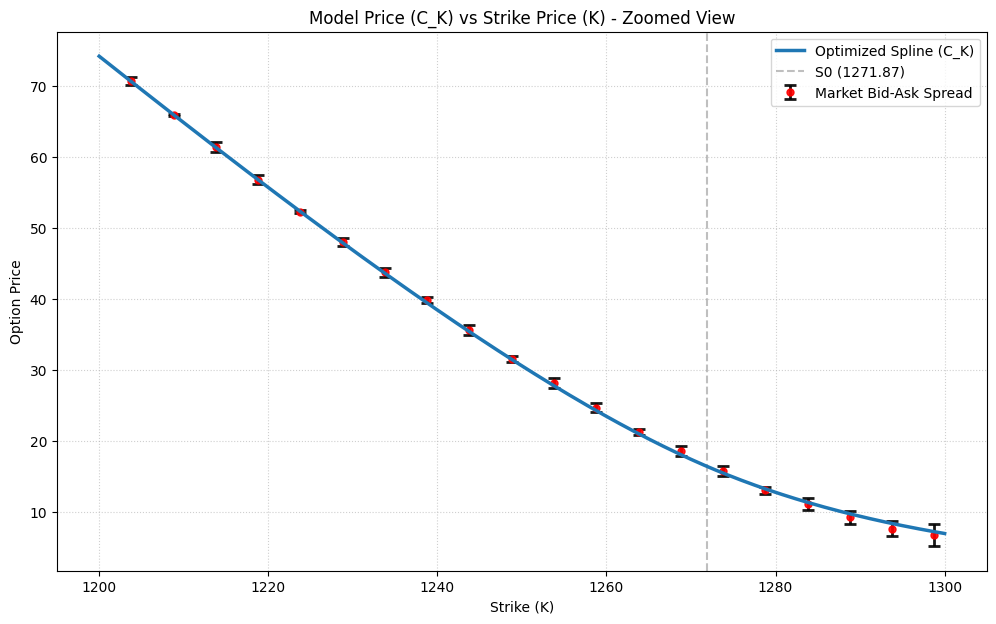

In [6]:
# 1. Define the range for K
nus1 = opt_theta[0:R1]
nus2 = opt_theta[2*R1 : 2*R1 + R2]

k_min = 1200
k_max = 1300

# Generate a smooth range of K values for the model line
K_plot = np.linspace(k_min, k_max, 500)

# 2. Pre-calculate c_v values
c_v1_opt, c_v2_opt = load_c_values(R1, R2, S0, opt_theta)

# 3. Calculate model prices
model_prices = np.array([C_K(k, R1, R2, S0, opt_theta, c_v1_opt, c_v2_opt) for k in K_plot])

# 4. Filter market data
mask = (market_bid_ask[:, 0] >= k_min) & (market_bid_ask[:, 0] <= k_max)
market_subset = market_bid_ask[mask]

strikes = market_subset[:, 0]
bids = market_subset[:, 1]
asks = market_subset[:, 2]
mid_prices = (bids + asks) / 2
yerr = [(mid_prices - bids), (asks - mid_prices)]

# 5. Plotting with enhanced error bars
plt.figure(figsize=(12, 7))

# Plot the spline model
plt.plot(K_plot, model_prices, color='#1f77b4', label='Optimized Spline (C_K)', linewidth=2.5, zorder=3)

# Add more apparent market bid-ask error bars
plt.errorbar(strikes, mid_prices, yerr=yerr, fmt='o', color='red',
             ecolor='black', elinewidth=2, capsize=4, capthick=2, markersize=5,
             label='Market Bid-Ask Spread', alpha=0.9, zorder=2)

plt.axvline(S0, color='gray', linestyle='--', alpha=0.5, label=f'S0 ({S0})')
plt.title('Model Price (C_K) vs Strike Price (K) - Zoomed View')
plt.xlabel('Strike (K)')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# A plot of C" / V.

# It's clear that this is equivalent to the piecewise graph of $\frac{1}{σ_i^2}$. It's easy to see from the formula of C", further, you can see the piecewise regions below are flat.

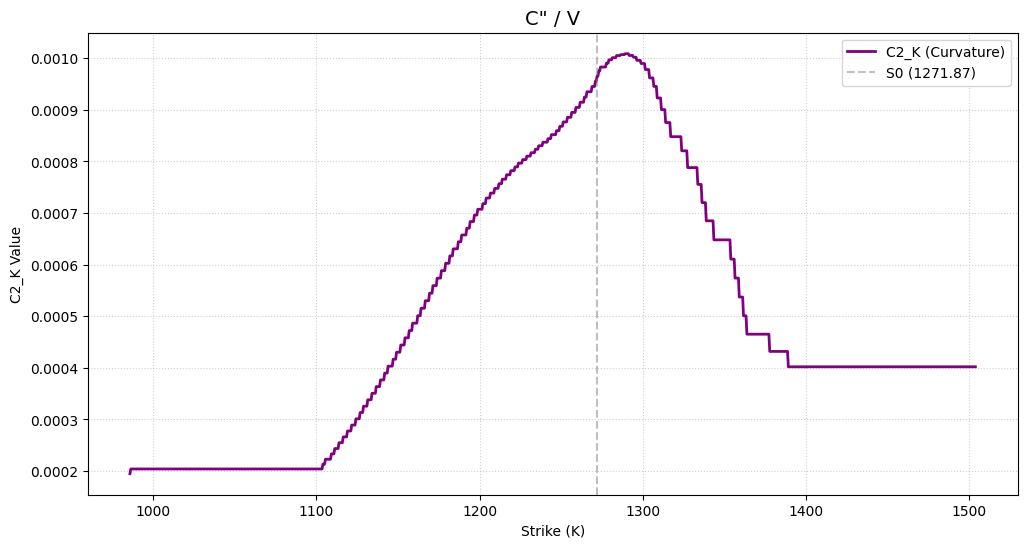

In [7]:
# 1. Pre-calculate c_v values for the optimized theta
c_v1_opt, c_v2_opt = load_c_values(R1, R2, S0, opt_theta)

# 2. Extract the range from nus[1] to nus2[-2]
nus1 = opt_theta[0:R1]
nus2 = opt_theta[2*R1 : 2*R1 + R2]
k_min_plot = nus1[1]
k_max_plot = nus2[-2]

# 3. Generate strike range and calculate C2_K
K_range = np.linspace(k_min_plot, k_max_plot, 1000)
c2_values = np.array([C2_over_V(k, R1, R2, S0, opt_theta, c_v1_opt, c_v2_opt) for k in K_range])

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.plot(K_range, c2_values, color='purple', linewidth=2, label='C2_K (Curvature)')
plt.axvline(S0, color='gray', linestyle='--', alpha=0.5, label=f'S0 ({S0})')

plt.title('C" / V', fontsize=14)
plt.xlabel('Strike (K)')
plt.ylabel('C2_K Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Now we focus on inserting more nus where most needed. The process is as follows:

# Sort each nu by the size of its jump. Starting from the largest jump, check if placing an extra nu and sigma still satisfies market bounds. If not, move down to smaller jumps.

# To allow for more flexibility the added sigma is placed as a normal distribution around its optimal position. This placement is also re-run multiple times if it gets unlucky the first few times. The added nu, however, is added exactly halfway between its neighbors.

# After each insertion, our RCD is run to even out any weirdness from adding the extra nu and sigma.

In [8]:
def optimize_nus(R1, R2, S0, init_theta, bid_ask_arr, num_additions = 100, num_iterations = 100, tol=1e-5):
    theta = init_theta.copy()
    prev_total_loss = None

    for i in range(num_additions):
        nus1 = theta[:R1]
        sigs1 = theta[R1 : 2 * R1]
        nus2 = theta[2 * R1 : 2 * R1 + R2]
        sigs2 = theta[2 * R1 + R2 :]

        sigs = np.concatenate([sigs1, sigs2])
        nus = np.concatenate([nus1, [S0], nus2])

        diffs = np.abs(np.diff(1/sigs**2))
        sorted_indices = np.argsort(diffs)[::-1]

        found_improvement = False
        for index in sorted_indices:
            if index == R1-1: continue
            # Try inserting a new knot between index and index + 1
            target = np.sqrt(2) * sigs[index] * sigs[index+1] / np.sqrt(sigs[index]**2 + sigs[index+1]**2)
            scale = np.abs(sigs[index+1] - sigs[index]) / 4

            new_nu = nus[index+1] + (nus[index+2] - nus[index+1])/3
            temp_nus = np.insert(nus, index + 2, new_nu)
            temp_nus[index+1] = nus[index+1] - (nus[index+1] - nus[index])/3

            temp_nus = np.delete(temp_nus, R1)

            # Inner loop to run the normal distribution sampling multiple times per index
            for attempt in range(5):
                new_sig = np.random.normal(target, scale)

                temp_sigs = np.insert(sigs, index + 1, new_sig)


                # Update R1 or R2 based on where we inserted
                new_R1, new_R2 = R1, R2
                if index < R1:
                    new_R1 += 1
                else:
                    new_R2 += 1

                # Reconstruct theta
                new_theta = np.concatenate([
                    temp_nus[:new_R1],
                    temp_sigs[:new_R1],
                    temp_nus[new_R1:],
                    temp_sigs[new_R1:]
                ])

                if validate_and_check_market(new_R1, new_R2, S0, new_theta, bid_ask_arr):
                    theta = new_theta
                    R1, R2 = new_R1, new_R2
                    found_improvement = True
                    print(f"Added knot at index {index+1} on attempt {attempt+1}. New R1: {R1}, R2: {R2}")
                    break

            if found_improvement:
                break

        if not found_improvement:
            print("No valid knot additions found that satisfy market constraints.")
            break

        # Refine the new configuration with Coordinate Descent
        theta = coordinateDescent(R1, R2, S0, theta, bid_ask_arr, num_iterations=num_iterations)

        current_sigs = np.concatenate([theta[R1:2*R1], theta[2*R1+R2:]])
        current_loss = newObjective(current_sigs)

        if prev_total_loss is not None and abs(prev_total_loss - current_loss) < tol:
            print(f"Stopping addition loop at {i} additions due to convergence.")
            break
        prev_total_loss = current_loss

    return R1, R2, theta

# Here, we run on our partially optimized theta from a few cells ago.

# Right now, its set to add 500 extra nus and sigmas, running RCD for 50 iterations after each one.


Starting refinement from R1=70, R2=34
Added knot at index 96 on attempt 1. New R1: 70, R2: 35
Iteration 0/50 | Loss: -17.396989
Added knot at index 98 on attempt 1. New R1: 70, R2: 36
Iteration 0/50 | Loss: -17.430886
Added knot at index 100 on attempt 5. New R1: 70, R2: 37
Iteration 0/50 | Loss: -17.449837
Added knot at index 104 on attempt 1. New R1: 70, R2: 38
Iteration 0/50 | Loss: -17.491275
Added knot at index 93 on attempt 1. New R1: 70, R2: 39
Iteration 0/50 | Loss: -17.523630
Added knot at index 95 on attempt 1. New R1: 70, R2: 40
Iteration 0/50 | Loss: -17.557827
Added knot at index 91 on attempt 1. New R1: 70, R2: 41
Iteration 0/50 | Loss: -17.582167
Added knot at index 89 on attempt 1. New R1: 70, R2: 42
Iteration 0/50 | Loss: -17.607280
Added knot at index 107 on attempt 1. New R1: 70, R2: 43
Iteration 0/50 | Loss: -17.621381
Added knot at index 102 on attempt 1. New R1: 70, R2: 44
Iteration 0/50 | Loss: -17.635285
Added knot at index 106 on attempt 1. New R1: 70, R2: 45
I

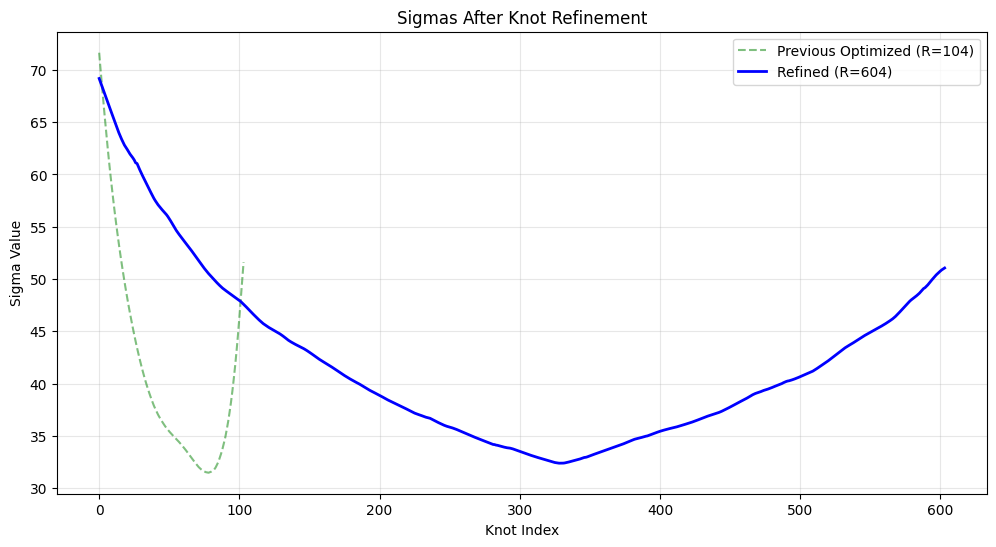

In [9]:
print(f"Starting refinement from R1={R1}, R2={R2}")

# Run the refinement function
# We'll do 5 additions, each followed by 500 iterations of CCD
new_R1, new_R2, refined_theta = optimize_nus(
    R1, R2, S0, opt_theta, market_bid_ask,
    num_additions=500,
    num_iterations=50
)

# Visualize the final sigmas compared to the previous optimization
refined_sigs = np.concatenate([refined_theta[new_R1 : 2*new_R1], refined_theta[2*new_R1 + new_R2 :]])

plt.figure(figsize=(12, 6))
plt.plot(opt_sigs, 'g--', alpha=0.5, label=f'Previous Optimized (R={R1+R2})')
plt.plot(refined_sigs, 'b-', linewidth=2, label=f'Refined (R={new_R1+new_R2})')
plt.title('Sigmas After Knot Refinement')
plt.xlabel('Knot Index')
plt.ylabel('Sigma Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Extremely good J

# Also, looking at the graph of sigmas above it has become a lot more uniform

In [10]:
import numpy as np

# Calculate J for refined parameters
c_v1_ref, c_v2_ref = load_c_values(new_R1, new_R2, S0, refined_theta)
j_refined = calculate_J(new_R1, new_R2, S0, refined_theta, c_v1_ref, c_v2_ref)

print(f"Original J (Initial):   {j_init:.12f}")
print(f"Optimized J (Previous): {j_opt:.12f}")
print(f"Refined J (Final):     {j_refined:.12f}")

if j_refined < j_opt:
    improvement = (j_opt - j_refined) / j_opt * 100
    print(f"\nKnot refinement further reduced J by {improvement:.2f}%")
else:
    print("\nRefinement did not further reduce the jump metric.")

Original J (Initial):   0.001252886346
Optimized J (Previous): 0.000000421885
Refined J (Final):     0.000000051940

Knot refinement further reduced J by 87.69%


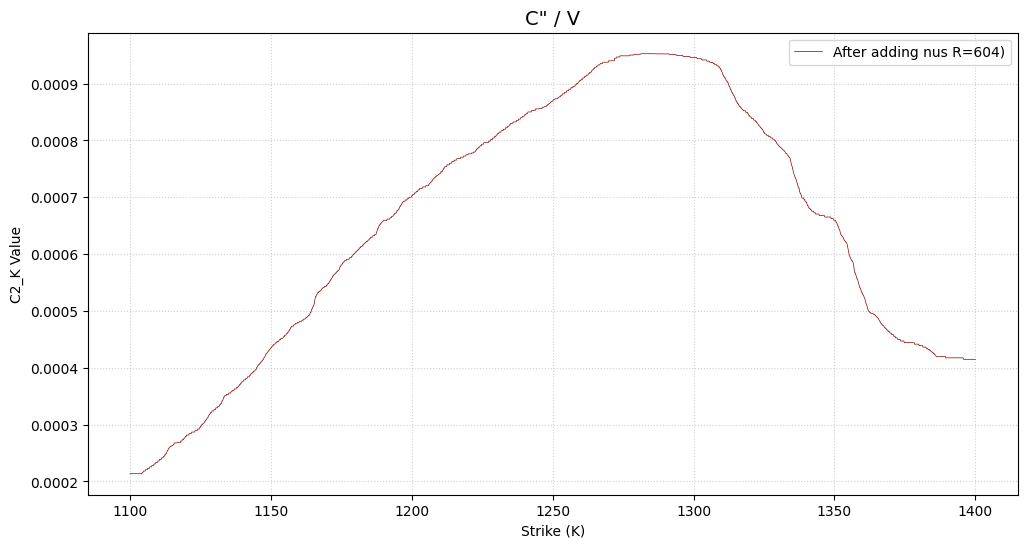

In [11]:
# 1. Pre-calculate c_v values for the refined theta
c_v1_ref, c_v2_ref = load_c_values(new_R1, new_R2, S0, refined_theta)

# 2. Extract the range from nus
nus1_ref = refined_theta[0:new_R1]
nus2_ref = refined_theta[2*new_R1 : 2*new_R1 + new_R2]
k_min_plot = 1100
k_max_plot = 1400

# 3. Generate strike range and calculate C2_K
K_range = np.linspace(k_min_plot, k_max_plot, 2000)
c2_values_ref = np.array([C2_over_V(k, new_R1, new_R2, S0, refined_theta, c_v1_ref, c_v2_ref) for k in K_range])

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.plot(K_range, c2_values_ref, color='darkred', linewidth=0.5, label=f'After adding nus R={new_R1+new_R2})')

plt.title('C" / V', fontsize=14)
plt.xlabel('Strike (K)')
plt.ylabel('C2_K Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Above is a graph of C" / V again.

# it looks a lot more complicated a rougher in a way but you can see the jumps are a lot smaller since there are just so many more intervals

Starting secondary CCD refinement from R=604 knots...
Iteration 0/30000 | Loss: -19.628639
Iteration 1000/30000 | Loss: -19.636588
Iteration 2000/30000 | Loss: -19.639692
Iteration 3000/30000 | Loss: -19.642324
Iteration 4000/30000 | Loss: -19.644341
Iteration 5000/30000 | Loss: -19.646467
Iteration 6000/30000 | Loss: -19.648409
Iteration 7000/30000 | Loss: -19.650058
Iteration 8000/30000 | Loss: -19.651634
Iteration 9000/30000 | Loss: -19.653006
Iteration 10000/30000 | Loss: -19.653952
Iteration 11000/30000 | Loss: -19.655056
Iteration 12000/30000 | Loss: -19.656574
Iteration 13000/30000 | Loss: -19.657863
Iteration 14000/30000 | Loss: -19.658908
Iteration 15000/30000 | Loss: -19.659653
Iteration 16000/30000 | Loss: -19.661057
Iteration 17000/30000 | Loss: -19.661852
Iteration 18000/30000 | Loss: -19.662741
Iteration 19000/30000 | Loss: -19.663631
Iteration 20000/30000 | Loss: -19.664386
Iteration 21000/30000 | Loss: -19.665104
Iteration 22000/30000 | Loss: -19.665719
Iteration 23000/

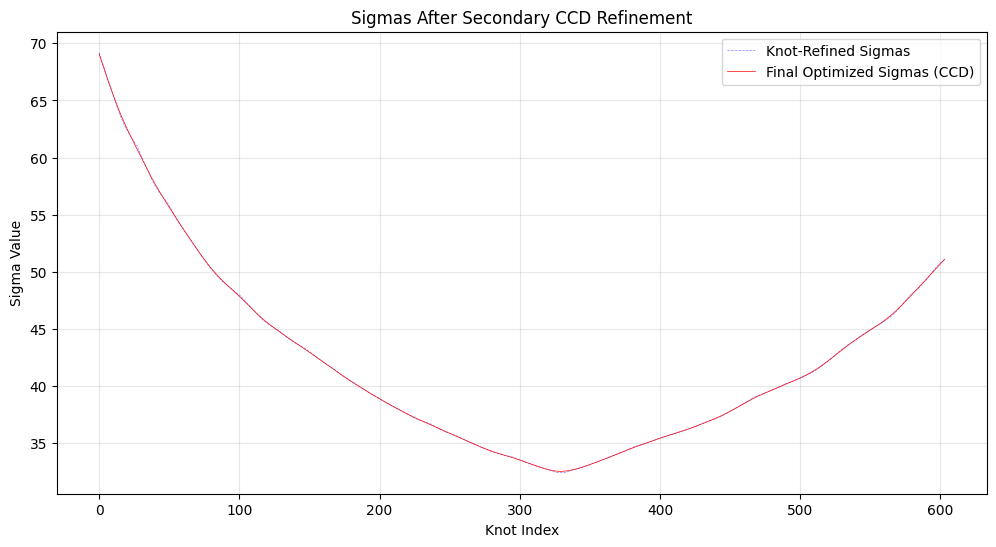

In [12]:
# Run CCD on the refined theta
print(f"Starting secondary CCD refinement from R={new_R1 + new_R2} knots...")
final_theta = coordinateDescent(new_R1, new_R2, S0, refined_theta, market_bid_ask, num_iterations=30000)

# Calculate final metrics
c_v1_final, c_v2_final = load_c_values(new_R1, new_R2, S0, final_theta)
j_final = calculate_J(new_R1, new_R2, S0, final_theta, c_v1_final, c_v2_final)

print(f"\nRefined J (Previous): {j_refined:.12f}")
print(f"Final J (After CCD):  {j_final:.12f}")
improvement_ccd = (j_refined - j_final) / j_refined * 100
print(f"Additional reduction in J: {improvement_ccd:.4f}%")

# Visualize sigmas
final_sigs = np.concatenate([final_theta[new_R1 : 2*new_R1], final_theta[2*new_R1 + new_R2 :]])

plt.figure(figsize=(12, 6))
plt.plot(refined_sigs, 'b--', linewidth=0.5, alpha=0.5, label='Knot-Refined Sigmas')
plt.plot(final_sigs, 'r-', linewidth=0.5, label='Final Optimized Sigmas (CCD)')
plt.title('Sigmas After Secondary CCD Refinement')
plt.xlabel('Knot Index')
plt.ylabel('Sigma Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Here we run RCD again for 30,000 iterations on top just for good measure.

# it really doesn't change sigmas all that much.

# Surprisingly though, it reduces our original objective J by a ton. huh

# Below is C" / V again, and i also plotted C" to compare with previous CCD attempt. C" is looking a lot better in that 1300 - 1340 region, there are still small weirdos in 1340 - 1360 range, but definitely a lot less noticeable.


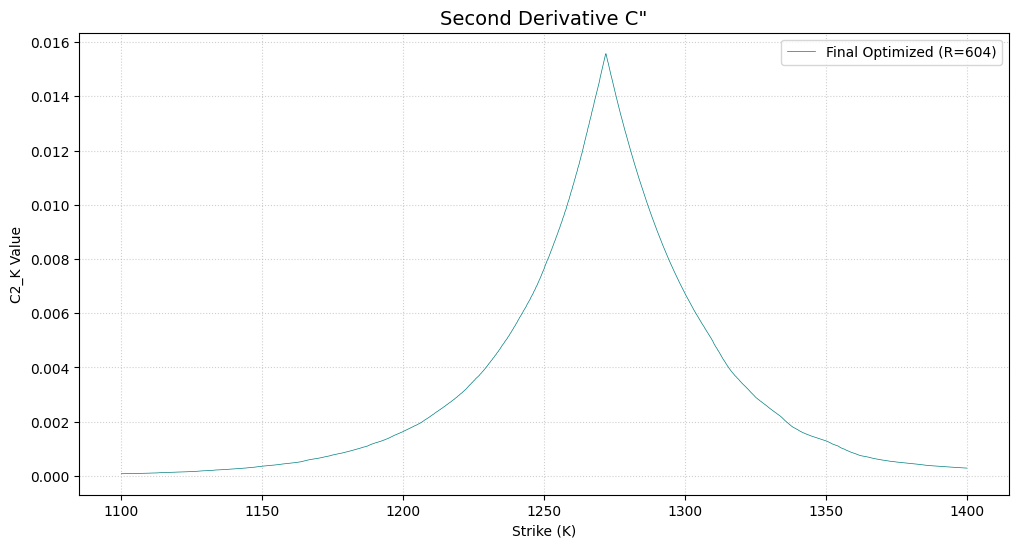

In [13]:
# 1. Pre-calculate c_v values for the final optimized theta
c_v1_fin, c_v2_fin = load_c_values(new_R1, new_R2, S0, final_theta)

# 2. Define strike range for plotting
k_min_plot = 1100
k_max_plot = 1400
K_range = np.linspace(k_min_plot, k_max_plot, 2000)

# 3. Calculate C2_K
c2_values_final = np.array([C2_K(k, new_R1, new_R2, S0, final_theta, c_v1_fin, c_v2_fin) for k in K_range])

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.plot(K_range, c2_values_final, color='teal', linewidth=0.5, label=f'Final Optimized (R={new_R1+new_R2})')

plt.title('Second Derivative C"', fontsize=14)
plt.xlabel('Strike (K)')
plt.ylabel('C2_K Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

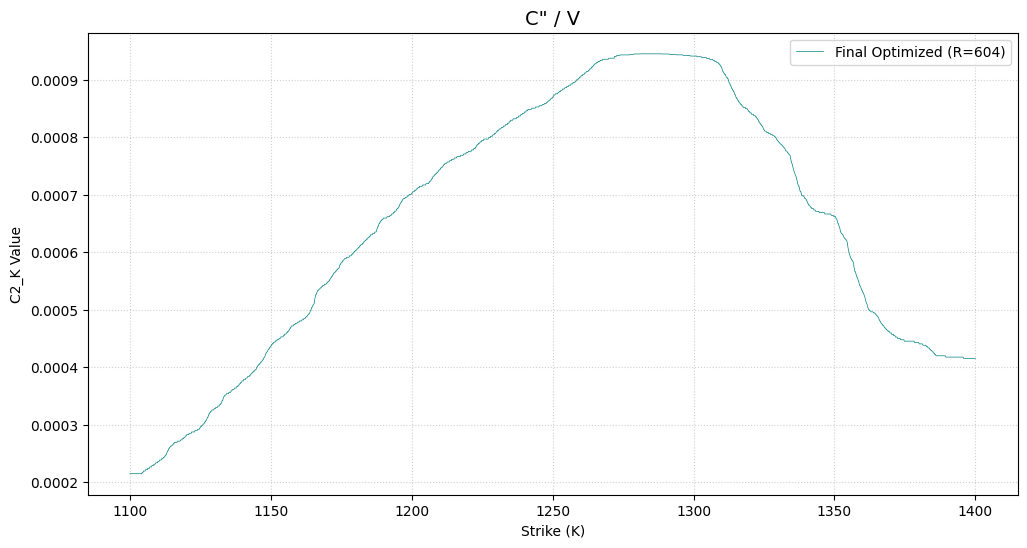

In [14]:
# 1. Pre-calculate c_v values for the final optimized theta
c_v1_fin, c_v2_fin = load_c_values(new_R1, new_R2, S0, final_theta)

# 2. Define strike range for plotting
k_min_plot = 1100
k_max_plot = 1400
K_range = np.linspace(k_min_plot, k_max_plot, 2000)

# 3. Calculate C2_K
c2_values_final = np.array([C2_over_V(k, new_R1, new_R2, S0, final_theta, c_v1_fin, c_v2_fin) for k in K_range])

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.plot(K_range, c2_values_final, color='teal', linewidth=0.5, label=f'Final Optimized (R={new_R1+new_R2})')

plt.title('C" / V', fontsize=14)
plt.xlabel('Strike (K)')
plt.ylabel('C2_K Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()